In [1]:
from typing import TypedDict, Annotated, Sequence
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import BaseMessage, ToolMessage, SystemMessage
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import add_messages
from load_dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
class AgentState(TypedDict):
  messages: Annotated[Sequence[BaseMessage], add_messages]


In [5]:
@tool
def int_to_float(a: int) -> float:
  """ Tool that converts integer input to float """
  print("int_to_float called")
  return float(a)

@tool
def float_to_int(a: float) -> int:
  """ Tool that converts float input to integer """
  print("float_to_int called")
  return float(a)

@tool
def add(a: float, b: float) -> float:
  """ Tool that takes two float input and outputs the sum as an float """
  print("add called")
  return a + b

tools = [add, int_to_float, float_to_int]

In [6]:
model = ChatOpenAI(model="gpt-4o-mini").bind_tools(tools)

In [7]:
def model_call(state: AgentState):
  system_prompt = SystemMessage(content=
        "You are my AI assistant, answer my questions to the best of your ability."
  )
  response = model.invoke([system_prompt] + state["messages"])
  return {"messages": [response]}

def should_continue(state: AgentState):
  messages = state["messages"]
  last_message = messages[-1]
  if not last_message.tool_calls:
    return "end"
  else:
    return "continue"

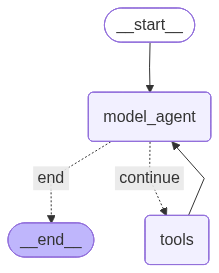

In [8]:
graph = StateGraph(AgentState)

graph.add_node("model_agent", model_call)

tool_node = ToolNode(tools=tools)
graph.add_node("tools", tool_node)

graph.add_edge(START, "model_agent")
graph.add_conditional_edges(
    "model_agent",
    should_continue,
    {
        "end": END,
        "continue": "tools"
    }
)

graph.add_edge("tools", "model_agent")

app = graph.compile()
display(app)

In [9]:
inputs = {"messages": [("user", "Add 5 + 23456. Add 2453+3564574. Add 34+5689. Convert 12.467 to int")]}
result = app.invoke(inputs)

add called
add called
add called
float_to_int called


In [10]:
print(result["messages"][-1].content)

Here are the results of your calculations:

1. \( 5 + 23456 = 23461 \)
2. \( 2453 + 3564574 = 3567027 \)
3. \( 34 + 5689 = 5723 \)
4. The integer conversion of \( 12.467 \) is \( 12 \) (the decimal part is discarded in the conversion).
